In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

column_names = [
    'poisonous', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
    'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
    'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
    'stalk_surface_below_ring', 'stalk_color_above_ring',
    'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
    'ring_type', 'spore_print_color', 'population', 'habitat'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'

full_df = pd.read_csv(url, header=None, names=column_names)
full_df.head()

,poisonous,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


use column names from NAMES file. print first 5 rows data to make sure everything is working so far.

In [27]:
df = full_df[['poisonous', 'odor', 'cap_color']].copy()
df.columns = ['Class', 'Odor', 'Cap_Color']
df.head()

,Class,Odor,Cap_Color
0,p,p,n
1,e,a,y
2,e,l,w
3,p,p,w
4,e,n,g


choose 3 categories (poisenous, odor, cap color) and print out first 5 rows.

In [28]:
class_map = {'e': 0, 'p': 1}

df['Class'] = df['Class'].map(class_map)

create a dictionary that says edible=0, poisonous=1. go through class columns and replace each value with either 0,1.

In [29]:
odor_map = {
    'a': 0,  # almond
    'l': 1,  # anise
    'c': 2,  # creosote
    'y': 3,  # fishy
    'f': 4,  # foul
    'm': 5,  # musty
    'n': 6,  # none
    'p': 7,  # pungent
    's': 8,  # spicy
}

df['Odor'] = df['Odor'].map(odor_map)

create dictionary map for odor. Go through odor columns and replace each value accordingly.

In [30]:
cap_map = {
    'n': 0,  # brown
    'b': 1,  # buff
    'c': 2,  # cinnamon
    'g': 3,  # gray
    'r': 4,  # green
    'p': 5,  # pink
    'u': 6,  # purple
    'e': 7,  # red
    'w': 8,  # white
    'y': 9,  # yellow
}

df['Cap_Color'] = df['Cap_Color'].map(cap_map)

create dictionary map for cap color. Go through cap color columns and replace each value accordingly.

In [31]:
df.head()

,Class,Odor,Cap_Color
0,1,7,0
1,0,0,9
2,0,1,8
3,1,7,8
4,0,6,3


print data. make sure values were replaces correctly.

In [32]:
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {0: '#2ecc71', 1: '#e74c3c'}

create chart with colors 0=edible=green, 1=poisonous=red

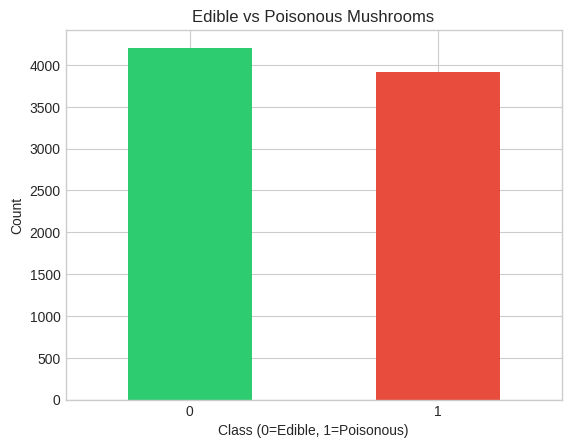

In [33]:
df['Class'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])

plt.title('Edible vs Poisonous Mushrooms')
plt.xlabel('Class (0=Edible, 1=Poisonous)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

title the chart and axis. print chart.

In [40]:
odor_labels = {
    0: 'Almond', 1: 'Anise', 2: 'Creosote', 3: 'Fishy',
    4: 'Foul', 5: 'Musty', 6: 'None', 7: 'Pungent', 8: 'Spicy'
}

odor_counts = df.groupby(['Odor', 'Class']).size().unstack()
odor_counts.index = [odor_labels[i] for i in odor_counts.index]
odor_counts.columns = ['Edible', 'Poisonous']


Count how many mushrooms there are for each odor + class, then turn it into a table. Replace odor codes with readable names. Rename the columns to clear labels.

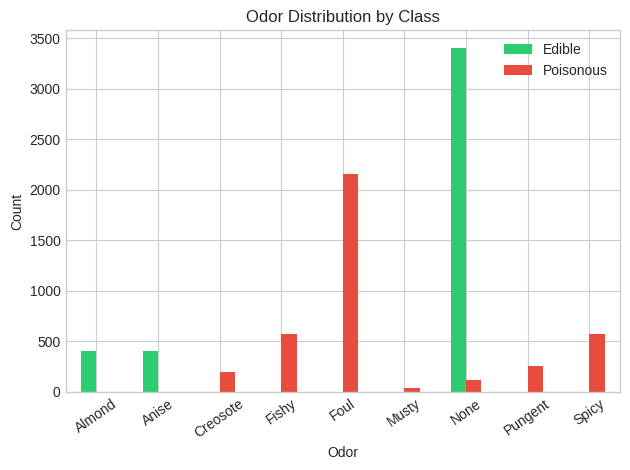

In [41]:
odor_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Odor Distribution by Class')
plt.xlabel('Odor')
plt.ylabel('Count')
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()

Plot chart and name axis. tight_layout()automatically fix spacing. Print chart.

In [42]:
cap_labels = {
    0: 'Brown', 1: 'Buff', 2: 'Cinnamon', 3: 'Gray',
    4: 'Green', 5: 'Pink', 6: 'Purple', 7: 'Red', 8: 'White', 9: 'Yellow'
}

cap_counts = df.groupby(['Cap_Color', 'Class']).size().unstack()
cap_counts.index = [cap_labels[i] for i in cap_counts.index]
cap_counts.columns = ['Edible', 'Poisonous']

Count how many mushrooms there are for each cap color + class, then turn it into a table. Replace cap codes with readable names. Rename the columns to clear labels.

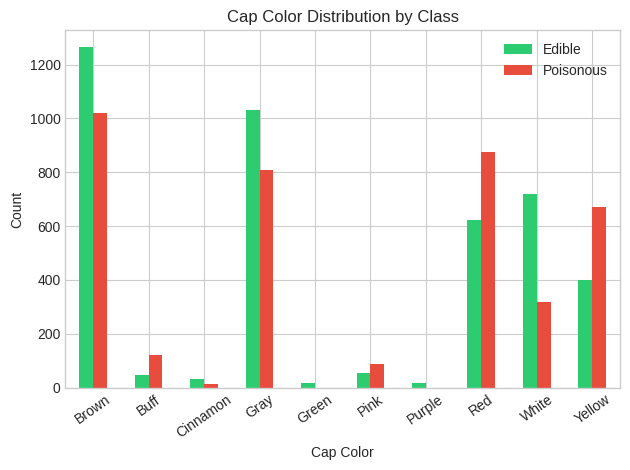

In [43]:
cap_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Cap Color Distribution by Class')
plt.xlabel('Cap Color')
plt.ylabel('Count')
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()

Plot chart and name axis. Print chart.



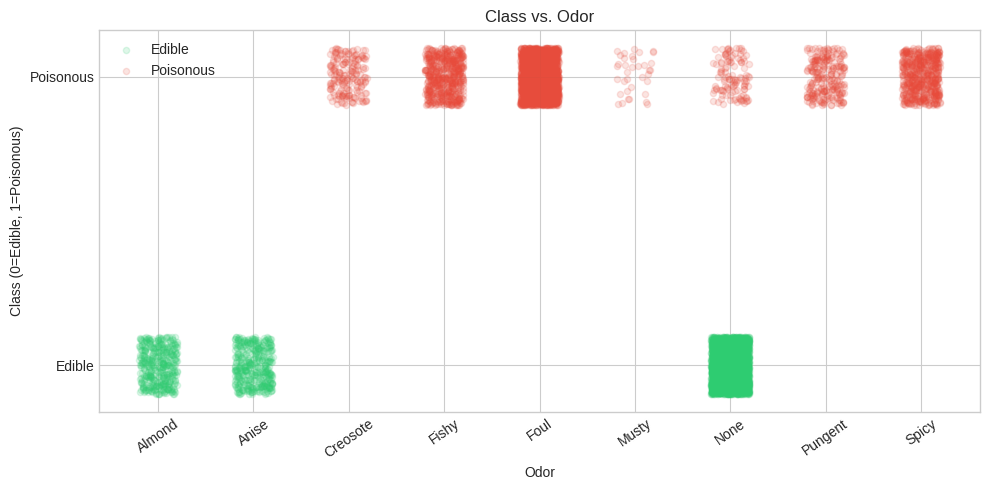

In [50]:
import numpy as np

np.random.seed(42)
plt.figure(figsize=(10, 5))

for cls, label, color in [(0, 'Edible', '#2ecc71'), (1, 'Poisonous', '#e74c3c')]:
    subset = df[df['Class'] == cls]
    plt.scatter(
        subset['Odor'] + np.random.uniform(-0.2, 0.2, size=len(subset)),
        subset['Class'] + np.random.uniform(-0.1, 0.1, size=len(subset)),
        alpha=0.15, s=20, color=color, label=label
    )

plt.title('Class vs. Odor')
plt.xlabel('Odor')
plt.ylabel('Class (0=Edible, 1=Poisonous)')
plt.xticks(ticks=range(9), labels=['Almond','Anise','Creosote','Fishy','Foul','Musty','None','Pungent','Spicy'], rotation=35)
plt.yticks([0, 1], ['Edible', 'Poisonous'])
plt.legend()
plt.tight_layout()
plt.show()

Create a blank plot that’s 10 units wide and 5 tall. Random() helps scatter plots so they're not on top of each other. Loop twice: once for edible (0, green) and once for poisonous (1, red). Take only the rows that match the current class (either edible or poisonous). Plot chart and name axis. Print chart.

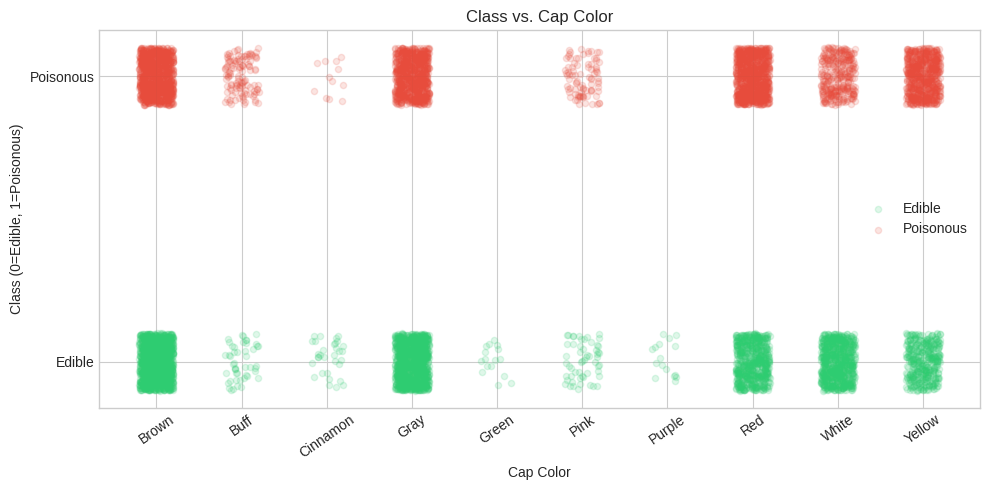

In [49]:
plt.figure(figsize=(10, 5))

for cls, label, color in [(0, 'Edible', '#2ecc71'), (1, 'Poisonous', '#e74c3c')]:
    subset = df[df['Class'] == cls]
    plt.scatter(
        subset['Cap_Color'] + np.random.uniform(-0.2, 0.2, size=len(subset)),
        subset['Class'] + np.random.uniform(-0.1, 0.1, size=len(subset)),
        alpha=0.15, s=20, color=color, label=label
    )

plt.title('Class vs. Cap Color')
plt.xlabel('Cap Color')
plt.ylabel('Class (0=Edible, 1=Poisonous)')
plt.xticks(ticks=range(10), labels=['Brown','Buff','Cinnamon','Gray','Green','Pink','Purple','Red','White','Yellow'], rotation=35)
plt.yticks([0, 1], ['Edible', 'Poisonous'])
plt.legend()
plt.tight_layout()
plt.show()

Loop through edible and poisenous.Keep only the rows that match the current group. Plot points for that group. Plot chart and name axis. Print chart.